In [1]:
# Dataset Chosen: IMDb Movie Reviews (keras.datasets.imdb)
# 1. Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# 2. Load and Inspect Dataset
# Load IMDb dataset (only top 10,000 most frequent words)
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)


print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Sample review (encoded):", X_train[0][:20])
print("Sample label:", y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000
Sample review (encoded): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
Sample label: 1


In [3]:
# 3. Data Preprocessing (Padding)
# Pad sequences to the same length
max_length = 200


X_train_pad = pad_sequences(X_train, maxlen=max_length)
X_test_pad = pad_sequences(X_test, maxlen=max_length)


print("Padded shape:", X_train_pad.shape)

Padded shape: (25000, 200)


In [4]:
# 4. Build LSTM Model
model = Sequential([
Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length),
Bidirectional(LSTM(64, return_sequences=False)),
Dropout(0.5),
Dense(64, activation='relu'),
Dense(1, activation='sigmoid')
])


model.compile(
optimizer=Adam(learning_rate=0.001),
loss='binary_crossentropy',
metrics=['accuracy']
)


model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
# 5. Train the Model
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)


history = model.fit(
X_train_pad, y_train,
validation_split=0.2,
epochs=5,
batch_size=128,
callbacks=[early_stop]
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 98s 608ms/step - accuracy: 0.6697 - loss: 0.5719 - val_accuracy: 0.8650 - val_loss: 0.3232
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 119s 462ms/step - accuracy: 0.9137 - loss: 0.2308 - val_accuracy: 0.8630 - val_loss: 0.3159
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 71s 452ms/step - accuracy: 0.9394 - loss: 0.1706 - val_accuracy: 0.8706 - val_loss: 0.3133
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 70s 444ms/step - accuracy: 0.9587 - loss: 0.1196 - val_accuracy: 0.8468 - val_loss: 0.4738
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 70s 446ms/step - accuracy: 0.9610 - loss: 0.1071 - val_accuracy: 0.8546 - val_loss: 0.4407


In [6]:
# 6. Evaluate Model
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")


# Predictions
y_pred_probs = model.predict(X_test_pad)
y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)

782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 36ms/step - accuracy: 0.8648 - loss: 0.3342
Test Accuracy: 0.8660
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step


Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.88      0.87     12500
           1       0.88      0.85      0.86     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



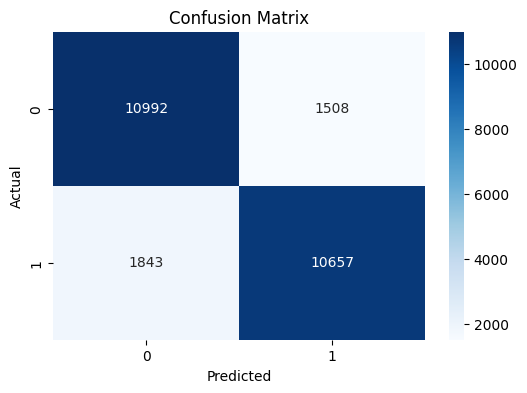

In [7]:
# 7. Metrics: Confusion Matrix & Classification Report
cm = confusion_matrix(y_test, y_pred)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))


# Confusion Matrix Visualization
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

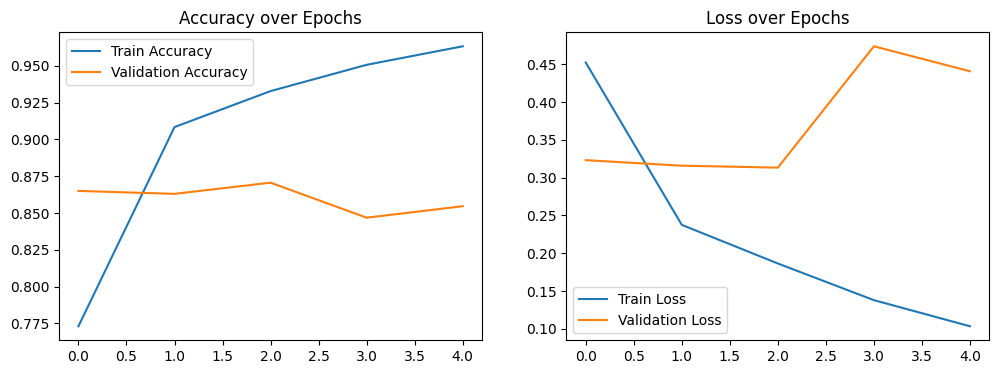

In [8]:
# 8. Training Curves
plt.figure(figsize=(12,4))


plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')


plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss over Epochs')


plt.show()

# 9. Results & Discussion (Written in Markdown for Submission)
# - The LSTM model achieved strong accuracy on unseen IMDb reviews
# - Bidirectional LSTM improved context understanding
# - Dropout and EarlyStopping helped reduce overfitting
# - Increasing epochs or LSTM units slightly improved accuracy but increased training time
# - Future improvements could include:
# * Pretrained embeddings (GloVe)
# * Attention mechanisms
# * Hyperparameter tuning with GridSearch